
[O3N2-M13] offset statistics for NGC4501:
  Σ_SFR mean: -2.035
  Σ_SFR offset range: -2.132 to 1.965
  Σ_SFR offset max absolute: ±2.132
  [O/H] mean: 8.575
  [O/H] offset range: -0.183 to 0.248
  [O/H] offset max absolute: ±0.248
  Valid pixels for Σ_SFR: 261083
  Valid pixels for [O/H]: 261083
  Common valid pixels: 261083

[O3N2-M13] offset statistics for NGC4501:
  Σ_SFR mean: -2.035
  Σ_SFR offset range: -2.132 to 1.965
  Σ_SFR offset max absolute: ±2.132
  [O/H] mean: 8.575
  [O/H] offset range: -0.183 to 0.248
  [O/H] offset max absolute: ±0.248
  Valid pixels for Σ_SFR: 261083
  Valid pixels for [O/H]: 261083
  Common valid pixels: 261083


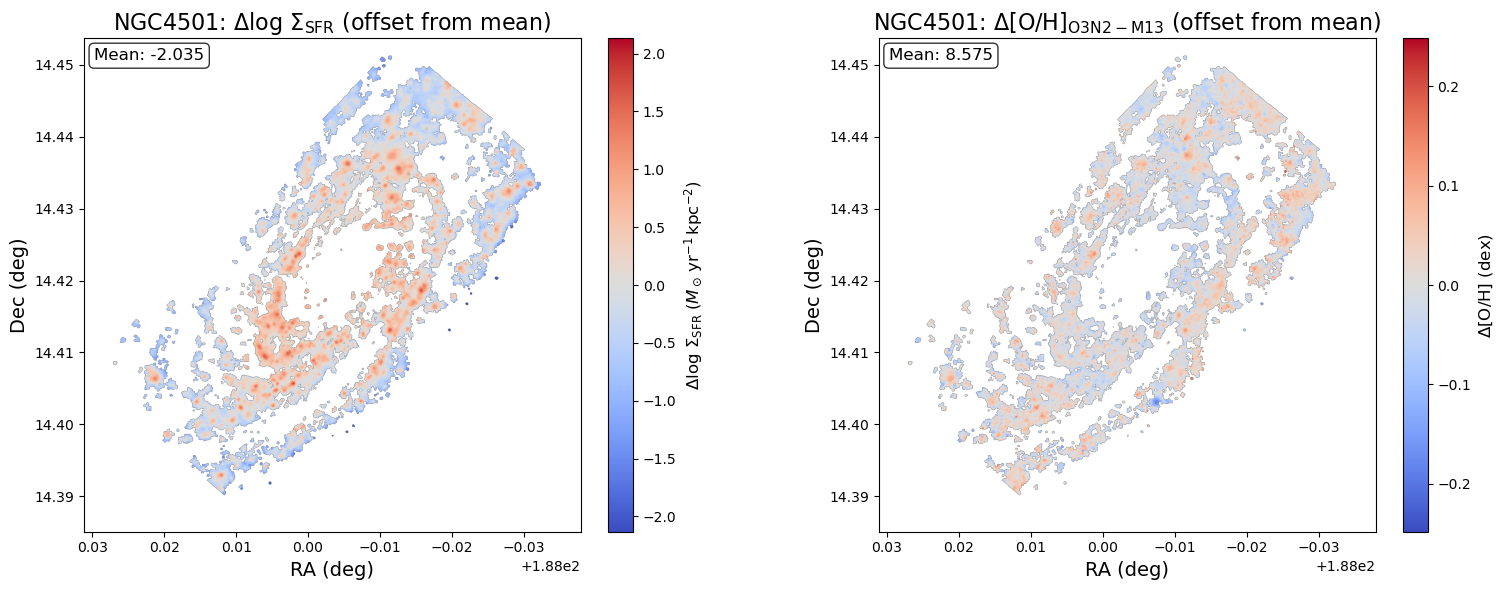

In [1]:
# ------------------------------------------------------------------
# 0.  Load NGC4501 maps and visualise Σ_SFR and [O/H] offset maps
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh

    # ------------------------------------------------------------------
    # 2.  Calculate mean values and create offset maps
    # ------------------------------------------------------------------
    # Calculate mean values for offset calculation
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
    
    # Create offset maps (difference from mean)
    sfr_offset = sigSFR - sfr_mean
    oh_offset = oh_o3n2_map - oh_mean
    
    # Calculate symmetric colorbar limits for offset maps
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_sfr]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_oh]))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Create figure: left = Σ_SFR offset, right = [O/H] offset
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR offset map (coolwarm, centered at 0)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    axes[0].set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from mean)', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Add mean value annotation on top left
    axes[0].text(0.02, 0.98, f'Mean: {sfr_mean:.3f}', transform=axes[0].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Right-hand side: [O/H] offset map (coolwarm, centered at 0)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                           extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    axes[1].set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from mean)', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=12)
    
    # Add mean value annotation on top left
    axes[1].text(0.02, 0.98, f'Mean: {oh_mean:.3f}', transform=axes[1].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # For reporting: offset statistics for the maps
    print(f"\n[{indicator_name}] offset statistics for {gal}:")
    print(f"  Σ_SFR mean: {sfr_mean:.3f}")
    print(f"  Σ_SFR offset range: {np.nanmin(sfr_offset[valid_sfr]):.3f} to {np.nanmax(sfr_offset[valid_sfr]):.3f}")
    print(f"  Σ_SFR offset max absolute: ±{sfr_offset_max:.3f}")
    print(f"  [O/H] mean: {oh_mean:.3f}")
    print(f"  [O/H] offset range: {np.nanmin(oh_offset[valid_oh]):.3f} to {np.nanmax(oh_offset[valid_oh]):.3f}")
    print(f"  [O/H] offset max absolute: ±{oh_offset_max:.3f}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Common valid pixels: {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_offset_maps.png', dpi=600)
    plt.show()

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_31560/1259540446.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


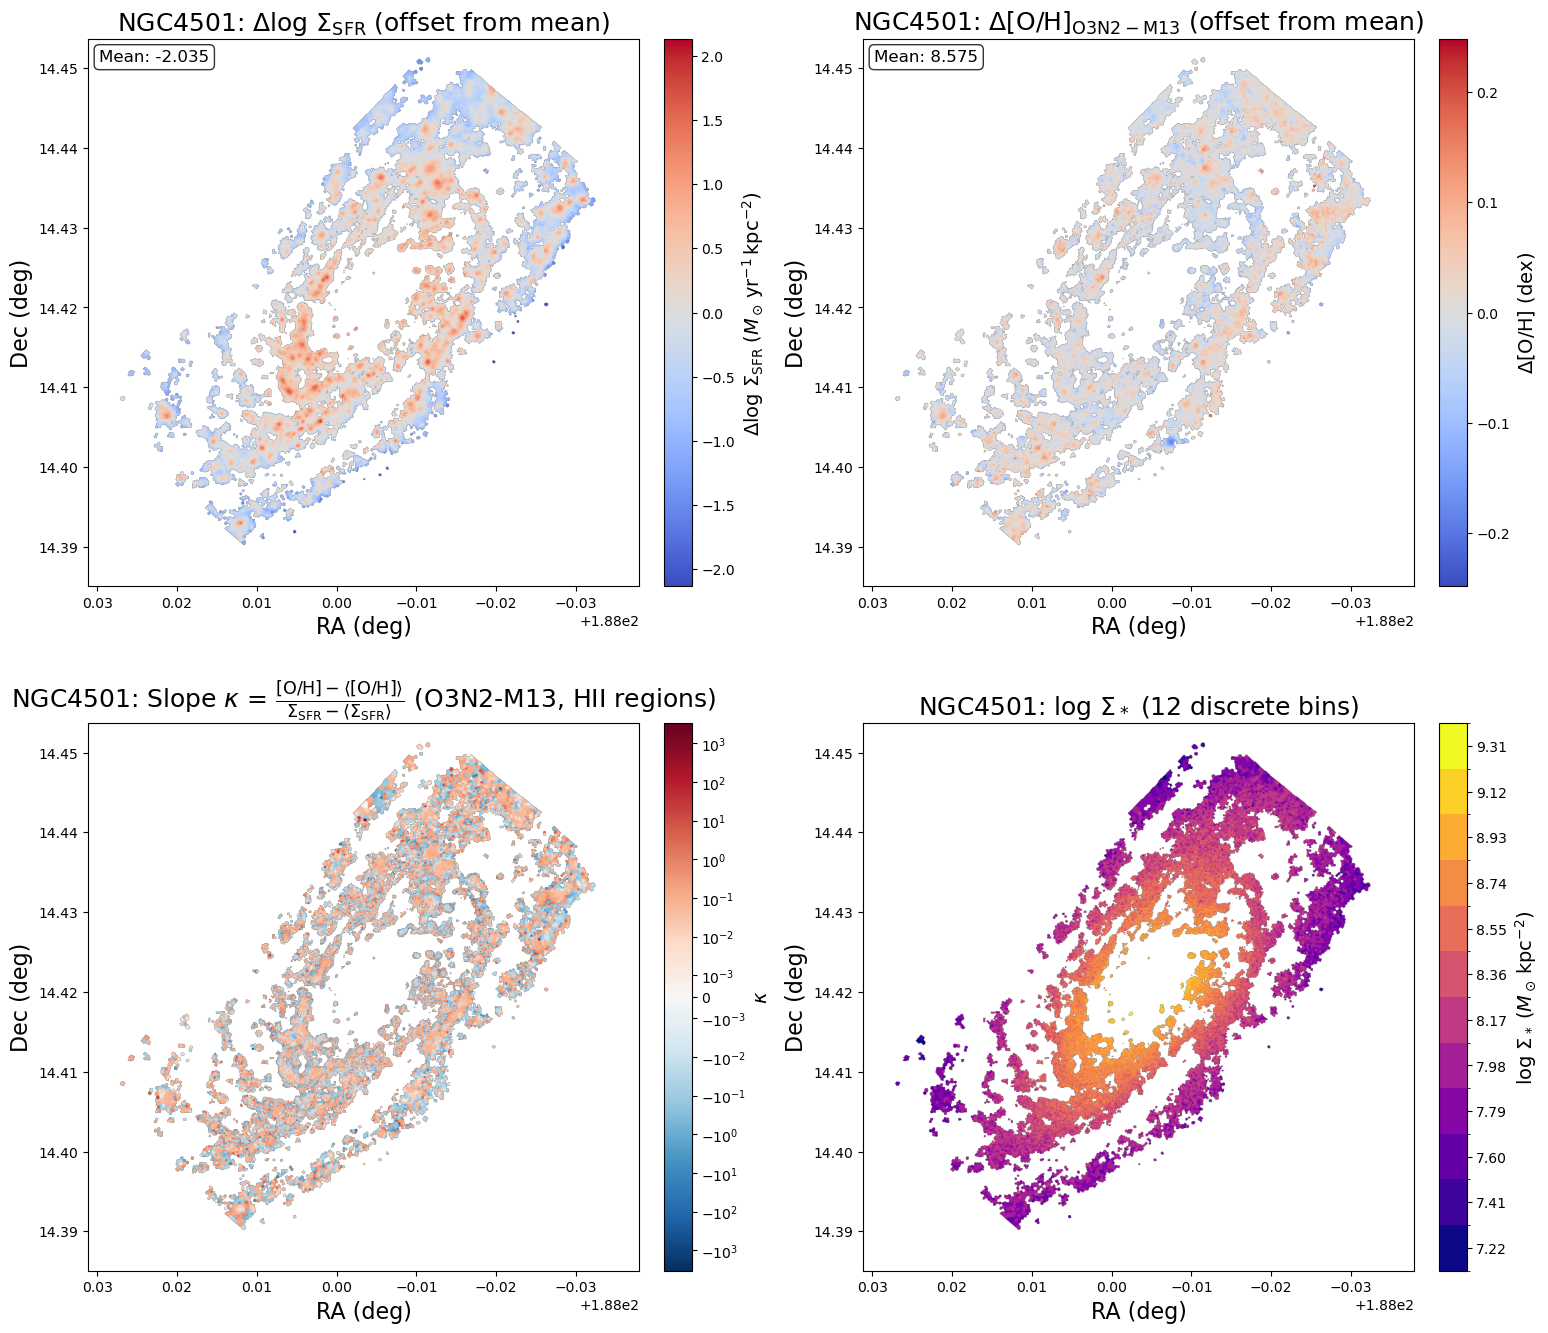


2x2 combined figure complete for NGC4501!
  Σ_SFR offset range: -2.132 to 2.132
  [O/H] offset range: -0.248 to 0.248
  κ range: -3347.893 to 1243.153
  Σ* bins: 12 bins from 7.128 to 9.407


In [2]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + slope map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate mean values and create offset maps
    # ------------------------------------------------------------------
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
    
    sfr_offset = sigSFR - sfr_mean
    oh_offset = oh_o3n2_map - oh_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_sfr]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_oh]))

    # ------------------------------------------------------------------
    # 3.  Calculate slope κ map (from cell 12)
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    kappa_map = np.full_like(sigM, np.nan)
    
    sigM_flat = sigM.flatten()
    sigSFR_flat = sigSFR.flatten()
    oh_flat = oh_o3n2_map.flatten()
    valid_all_flat = valid_all.flatten()
    kappa_flat = np.full_like(sigM_flat, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        elif i == n_bins - 1:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat <= sigmaM_bin_edges[i+1]) & valid_all_flat
        else:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        
        if np.sum(in_bin) > 0:
            x_bin = sigSFR_flat[in_bin]
            y_bin = oh_flat[in_bin]
            
            # Calculate the mean point: (x₀, y₀) = (mean(ΣSFR), mean([O/H]))
            x0 = np.mean(x_bin)
            y0 = np.mean(y_bin)
            
            dx = x_bin - x0
            dy = y_bin - y0
            
            kappa_bin = np.zeros_like(dx)
            nonzero_dx = np.abs(dx) > 1e-10
            kappa_bin[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
            kappa_bin[~nonzero_dx] = 0
            
            kappa_flat[in_bin] = kappa_bin
    
    kappa_map = kappa_flat.reshape(sigM.shape)

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    ax1.text(0.02, 0.98, f'Mean: {sfr_mean:.3f}', transform=ax1.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)
    
    ax2.text(0.02, 0.98, f'Mean: {oh_mean:.3f}', transform=ax2.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-left: Slope κ map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    kappa_max = np.nanmax(np.abs(kappa_map[valid_all]))
    linthresh = 0.001
    linscale = 0.5
    
    norm_kappa = SymLogNorm(linthresh=linthresh, linscale=linscale, 
                            vmin=-kappa_max, vmax=kappa_max)
    
    im_kappa = ax3.imshow(np.ma.masked_invalid(kappa_map), origin='lower', cmap='RdBu_r',
                          extent=extent, norm=norm_kappa)
    ax3.set_title(rf'{gal}: Slope $\kappa$ = $\frac{{[\mathrm{{O/H}}] - \langle[\mathrm{{O/H}}]\rangle}}{{\Sigma_{{\mathrm{{SFR}}}} - \langle\Sigma_{{\mathrm{{SFR}}}}\rangle}}$ ({indicator_name}, HII regions)', 
                  fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_kappa = fig.colorbar(im_kappa, ax=ax3, fraction=0.046, pad=0.04)
    cbar_kappa.set_label(r'$\kappa$', fontsize=14)

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    plt.savefig(f'{gal}_correlation_map_kappa.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{gal}_correlation_map_kappa.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  κ range: {np.nanmin(kappa_map[valid_all]):.3f} to {np.nanmax(kappa_map[valid_all]):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")

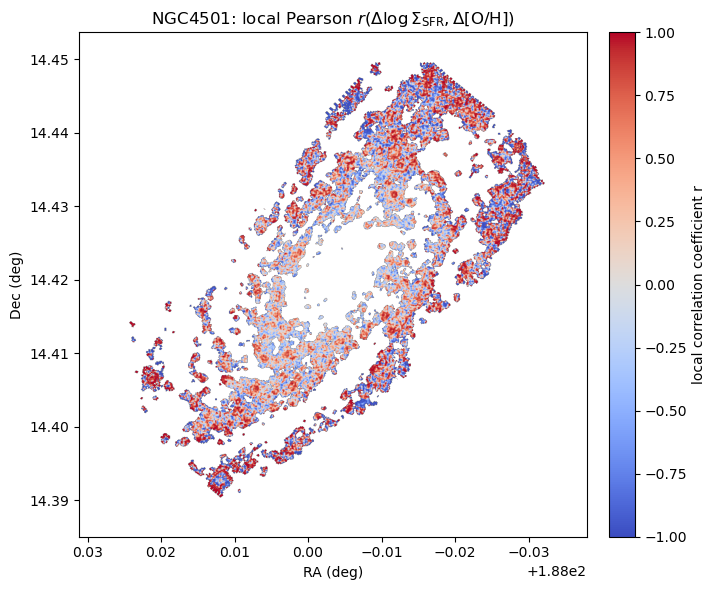

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def local_corr_map(A, B, valid_mask, half_win=2, min_n=10):
    """
    Compute a moving-window Pearson correlation between A and B.

    Parameters
    ----------
    A, B : 2D arrays
        Maps (e.g. sfr_offset, oh_offset).
    valid_mask : 2D bool
        True where both maps are valid.
    half_win : int
        Half window size in pixels (half_win=2 -> 5x5 window).
    min_n : int
        Minimum number of valid pixels in the window to compute a correlation.

    Returns
    -------
    corr_map : 2D array
        Map of local Pearson correlation coefficients in [-1, 1].
    """
    ny, nx = A.shape
    corr_map = np.full_like(A, np.nan, dtype=float)

    for i in range(ny):
        i0 = max(0, i - half_win)
        i1 = min(ny, i + half_win + 1)
        for j in range(nx):
            if not valid_mask[i, j]:
                continue
            j0 = max(0, j - half_win)
            j1 = min(nx, j + half_win + 1)

            win_valid = valid_mask[i0:i1, j0:j1]
            if np.count_nonzero(win_valid) < min_n:
                continue

            a_vals = A[i0:i1, j0:j1][win_valid]
            b_vals = B[i0:i1, j0:j1][win_valid]

            # need at least 2 unique values to define correlation
            if np.std(a_vals) == 0 or np.std(b_vals) == 0:
                continue

            r = np.corrcoef(a_vals, b_vals)[0, 1]
            corr_map[i, j] = r

    return corr_map

# --- compute and plot for NGC4501 ---
A = sfr_offset
B = oh_offset
valid = valid_all

corr_map = local_corr_map(A, B, valid_mask=valid, half_win=2, min_n=10)

fig, ax = plt.subplots(figsize=(7, 6))
v = np.nanmax(np.abs(corr_map))  # symmetric colour range
im = ax.imshow(np.ma.masked_invalid(corr_map), origin='lower',
               cmap='coolwarm', extent=extent, vmin=-v, vmax=v)
ax.set_title(r'NGC4501: local Pearson $r(\Delta\log\Sigma_{\rm SFR}, \Delta{\rm [O/H]})$')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('local correlation coefficient r')

plt.tight_layout()
plt.show()


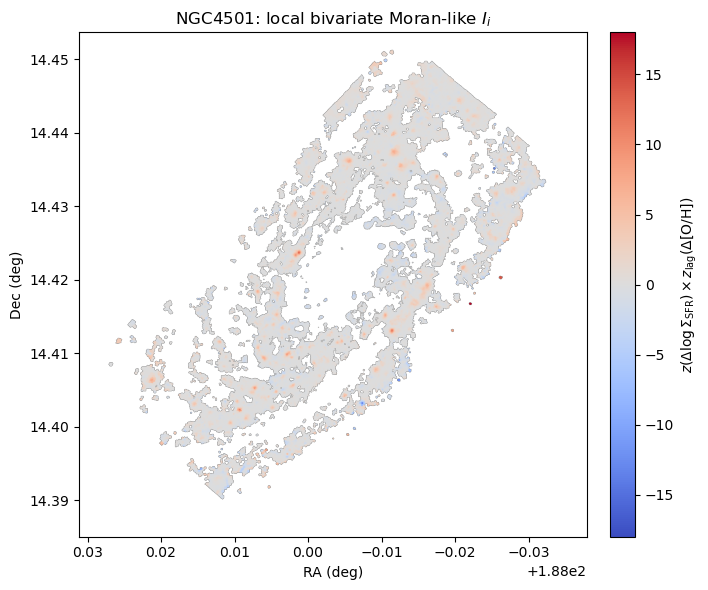

In [4]:
def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
    """
    Simple Moran-style local bivariate association between A and B.

    Parameters
    ----------
    A, B : 2D arrays
        Maps (e.g. sfr_offset, oh_offset).
    valid_mask : 2D bool
        True where both maps are valid.
    neighbourhood : {'queen', 'rook'}
        'queen' = 8-connected neighbours, 'rook' = 4-connected.

    Returns
    -------
    I_map : 2D array
        Local bivariate Moran-like statistic (sign & amplitude).
    quad_map : 2D int array
        Quadrant type:
        0 = invalid / no neighbours
        1 = high A, high lag(B)
        2 = low A,  high lag(B)
        3 = low A,  low lag(B)
        4 = high A, low lag(B)
    """
    ny, nx = A.shape
    I_map = np.full_like(A, np.nan, dtype=float)
    quad_map = np.zeros_like(A, dtype=int)

    # standardise A,B on valid pixels only
    Aval = A[valid_mask]
    Bval = B[valid_mask]
    Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
    Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

    if neighbourhood == 'queen':
        offsets = [(-1,-1), (-1,0), (-1,1),
                   ( 0,-1),          ( 0,1),
                   ( 1,-1), ( 1,0), ( 1,1)]
    elif neighbourhood == 'rook':
        offsets = [(-1,0), (0,-1), (0,1), (1,0)]
    else:
        raise ValueError("neighbourhood must be 'queen' or 'rook'")

    for i in range(ny):
        for j in range(nx):
            if not valid_mask[i, j]:
                continue

            # collect neighbouring Bz values
            neigh_vals = []
            for dy, dx in offsets:
                ii, jj = i + dy, j + dx
                if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                    neigh_vals.append(Bz[ii, jj])

            if len(neigh_vals) == 0:
                continue

            lag_B = np.mean(neigh_vals)   # spatial lag of B
            I_val = Az[i, j] * lag_B      # Moran-style product
            I_map[i, j] = I_val

            # quadrant classification (like LISA maps)
            if Az[i, j] >= 0 and lag_B >= 0:
                quad_map[i, j] = 1  # high A – high B_neigh
            elif Az[i, j] < 0 and lag_B >= 0:
                quad_map[i, j] = 2  # low A – high B_neigh
            elif Az[i, j] < 0 and lag_B < 0:
                quad_map[i, j] = 3  # low A – low B_neigh
            else:
                quad_map[i, j] = 4  # high A – low B_neigh

    return I_map, quad_map

# --- compute and plot for NGC4501 ---
I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                        neighbourhood='queen')

# amplitude map
fig, ax = plt.subplots(figsize=(7, 6))
vI = np.nanmax(np.abs(I_map))
imI = ax.imshow(np.ma.masked_invalid(I_map), origin='lower',
                cmap='coolwarm', extent=extent, vmin=-vI, vmax=vI)
ax.set_title(r'NGC4501: local bivariate Moran-like $I_i$')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
cbarI = fig.colorbar(imI, ax=ax, fraction=0.046, pad=0.04)
cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$')
plt.tight_layout()
plt.show()


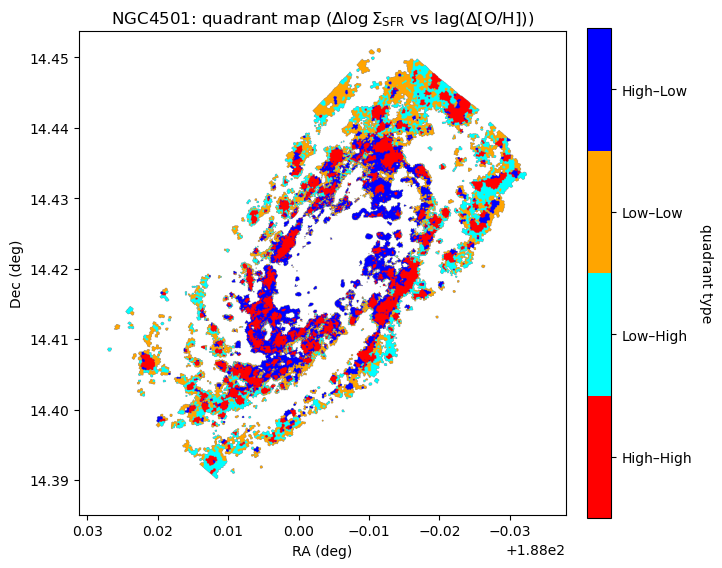

In [5]:
def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
    """
    Simple Moran-style local bivariate association between A and B.

    Parameters
    ----------
    A, B : 2D arrays
        Maps (e.g. sfr_offset, oh_offset).
    valid_mask : 2D bool
        True where both maps are valid.
    neighbourhood : {'queen', 'rook'}
        'queen' = 8-connected neighbours, 'rook' = 4-connected.

    Returns
    -------
    I_map : 2D array
        Local bivariate Moran-like statistic (sign & amplitude).
    quad_map : 2D int array
        Quadrant type:
        0 = invalid / no neighbours
        1 = high A, high lag(B)
        2 = low A,  high lag(B)
        3 = low A,  low lag(B)
        4 = high A, low lag(B)
    """
    ny, nx = A.shape
    I_map = np.full_like(A, np.nan, dtype=float)
    quad_map = np.zeros_like(A, dtype=int)

    # standardise A,B on valid pixels only
    Aval = A[valid_mask]
    Bval = B[valid_mask]
    Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
    Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

    if neighbourhood == 'queen':
        offsets = [(-1,-1), (-1,0), (-1,1),
                   ( 0,-1),          ( 0,1),
                   ( 1,-1), ( 1,0), ( 1,1)]
    elif neighbourhood == 'rook':
        offsets = [(-1,0), (0,-1), (0,1), (1,0)]
    else:
        raise ValueError("neighbourhood must be 'queen' or 'rook'")

    for i in range(ny):
        for j in range(nx):
            if not valid_mask[i, j]:
                continue

            # collect neighbouring Bz values
            neigh_vals = []
            for dy, dx in offsets:
                ii, jj = i + dy, j + dx
                if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                    neigh_vals.append(Bz[ii, jj])

            if len(neigh_vals) == 0:
                continue

            lag_B = np.mean(neigh_vals)   # spatial lag of B
            I_val = Az[i, j] * lag_B      # Moran-style product
            I_map[i, j] = I_val

            # quadrant classification (like LISA maps)
            if Az[i, j] >= 0 and lag_B >= 0:
                quad_map[i, j] = 1  # high A – high B_neigh
            elif Az[i, j] < 0 and lag_B >= 0:
                quad_map[i, j] = 2  # low A – high B_neigh
            elif Az[i, j] < 0 and lag_B < 0:
                quad_map[i, j] = 3  # low A – low B_neigh
            else:
                quad_map[i, j] = 4  # high A – low B_neigh

    return I_map, quad_map

# --- compute and plot for NGC4501 ---
I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                        neighbourhood='queen')

# quad_map values:
# 0 = invalid / no neighbours
# 1 = High A – High lag(B)   (High–High)
# 2 = Low A  – High lag(B)   (Low–High)
# 3 = Low A  – Low lag(B)    (Low–Low)
# 4 = High A – Low lag(B)    (High–Low)

# mask invalid
quad_valid = np.where(quad_map == 0, np.nan, quad_map)

# we shift values from {1,2,3,4} -> {0,1,2,3} for nicer colourbar
quad_display = quad_valid - 1

quad_cmap = ListedColormap(['red', 'cyan', 'orange', 'blue'])
bounds = np.array([-0.5, 0.5, 1.5, 2.5, 3.5])  # bin edges
ticks = np.array([0, 1, 2, 3])                 # centres
ticklabels = ['High–High', 'Low–High', 'Low–Low', 'High–Low']

fig, ax = plt.subplots(figsize=(7, 6))
imQ = ax.imshow(np.ma.masked_invalid(quad_display),
                origin='lower', extent=extent,
                cmap=quad_cmap, vmin=-0.5, vmax=3.5)

ax.set_title(r'NGC4501: quadrant map ($\Delta\log\Sigma_{\rm SFR}$ vs lag($\Delta{\rm [O/H]}$))')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')

cbarQ = fig.colorbar(imQ, ax=ax, boundaries=bounds, ticks=ticks,
                     fraction=0.046, pad=0.04)
cbarQ.ax.set_yticklabels(ticklabels)
cbarQ.set_label('quadrant type', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


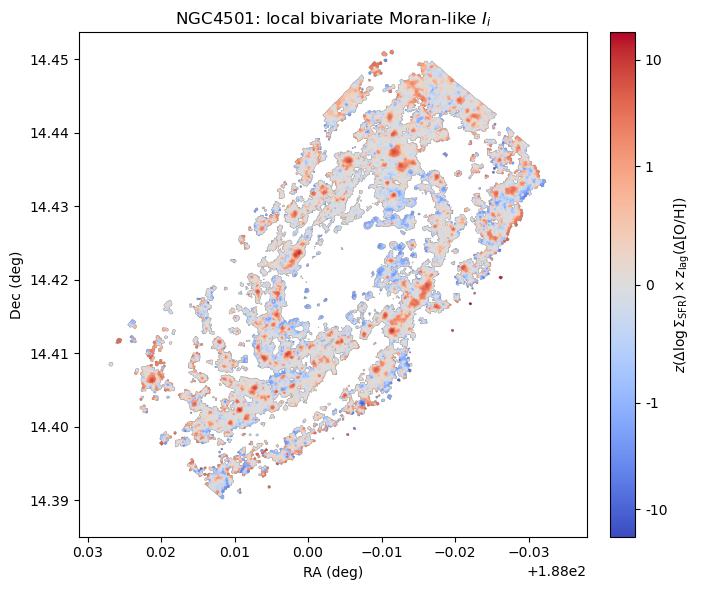

In [6]:
def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
    """
    Simple Moran-style local bivariate association between A and B.

    Parameters
    ----------
    A, B : 2D arrays
        Maps (e.g. sfr_offset, oh_offset).
    valid_mask : 2D bool
        True where both maps are valid.
    neighbourhood : {'queen', 'rook'}
        'queen' = 8-connected neighbours, 'rook' = 4-connected.

    Returns
    -------
    I_map : 2D array
        Local bivariate Moran-like statistic (sign & amplitude).
    quad_map : 2D int array
        Quadrant type:
        0 = invalid / no neighbours
        1 = high A, high lag(B)
        2 = low A,  high lag(B)
        3 = low A,  low lag(B)
        4 = high A, low lag(B)
    """
    ny, nx = A.shape
    I_map = np.full_like(A, np.nan, dtype=float)
    quad_map = np.zeros_like(A, dtype=int)

    # standardise A,B on valid pixels only
    Aval = A[valid_mask]
    Bval = B[valid_mask]
    Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
    Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

    if neighbourhood == 'queen':
        offsets = [(-1,-1), (-1,0), (-1,1),
                   ( 0,-1),          ( 0,1),
                   ( 1,-1), ( 1,0), ( 1,1)]
    elif neighbourhood == 'rook':
        offsets = [(-1,0), (0,-1), (0,1), (1,0)]
    else:
        raise ValueError("neighbourhood must be 'queen' or 'rook'")

    for i in range(ny):
        for j in range(nx):
            if not valid_mask[i, j]:
                continue

            # collect neighbouring Bz values
            neigh_vals = []
            for dy, dx in offsets:
                ii, jj = i + dy, j + dx
                if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                    neigh_vals.append(Bz[ii, jj])

            if len(neigh_vals) == 0:
                continue

            lag_B = np.mean(neigh_vals)   # spatial lag of B
            I_val = Az[i, j] * lag_B      # Moran-style product
            I_map[i, j] = I_val

            # quadrant classification (like LISA maps)
            if Az[i, j] >= 0 and lag_B >= 0:
                quad_map[i, j] = 1  # high A – high B_neigh
            elif Az[i, j] < 0 and lag_B >= 0:
                quad_map[i, j] = 2  # low A – high B_neigh
            elif Az[i, j] < 0 and lag_B < 0:
                quad_map[i, j] = 3  # low A – low B_neigh
            else:
                quad_map[i, j] = 4  # high A – low B_neigh

    return I_map, quad_map

# --- compute and plot for NGC4501 ---
I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                        neighbourhood='queen')

fig, ax = plt.subplots(figsize=(7, 6))

# max absolute value for symmetric limits
vI = np.nanmax(np.abs(I_map))

# Symmetric log-normalisation:
#  - linthresh=1.0   → values between -1 and 1 are on a linear scale
#  - outside this, log10 scaling, symmetric around 0
norm = SymLogNorm(linthresh=1.0, linscale=1.0,
                  vmin=-vI, vmax=vI, base=10)

imI = ax.imshow(np.ma.masked_invalid(I_map), origin='lower',
                cmap='coolwarm', extent=extent, norm=norm)

ax.set_title(r'NGC4501: local bivariate Moran-like $I_i$')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')

cbarI = fig.colorbar(imI, ax=ax, fraction=0.046, pad=0.04)
cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$')

# Nice symmetric log-style ticks (…,-10,-3,-1,0,1,3,10,…)
max_pow = int(np.floor(np.log10(vI)))
pos_ticks = [10**k for k in range(0, max_pow+1) if 10**k <= vI]
ticks = [-p for p in reversed(pos_ticks)] + [0.0] + pos_ticks
cbarI.set_ticks(ticks)
cbarI.set_ticklabels([f'{t:g}' for t in ticks])

plt.tight_layout()
plt.show()


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_31560/1421594355.py:261: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


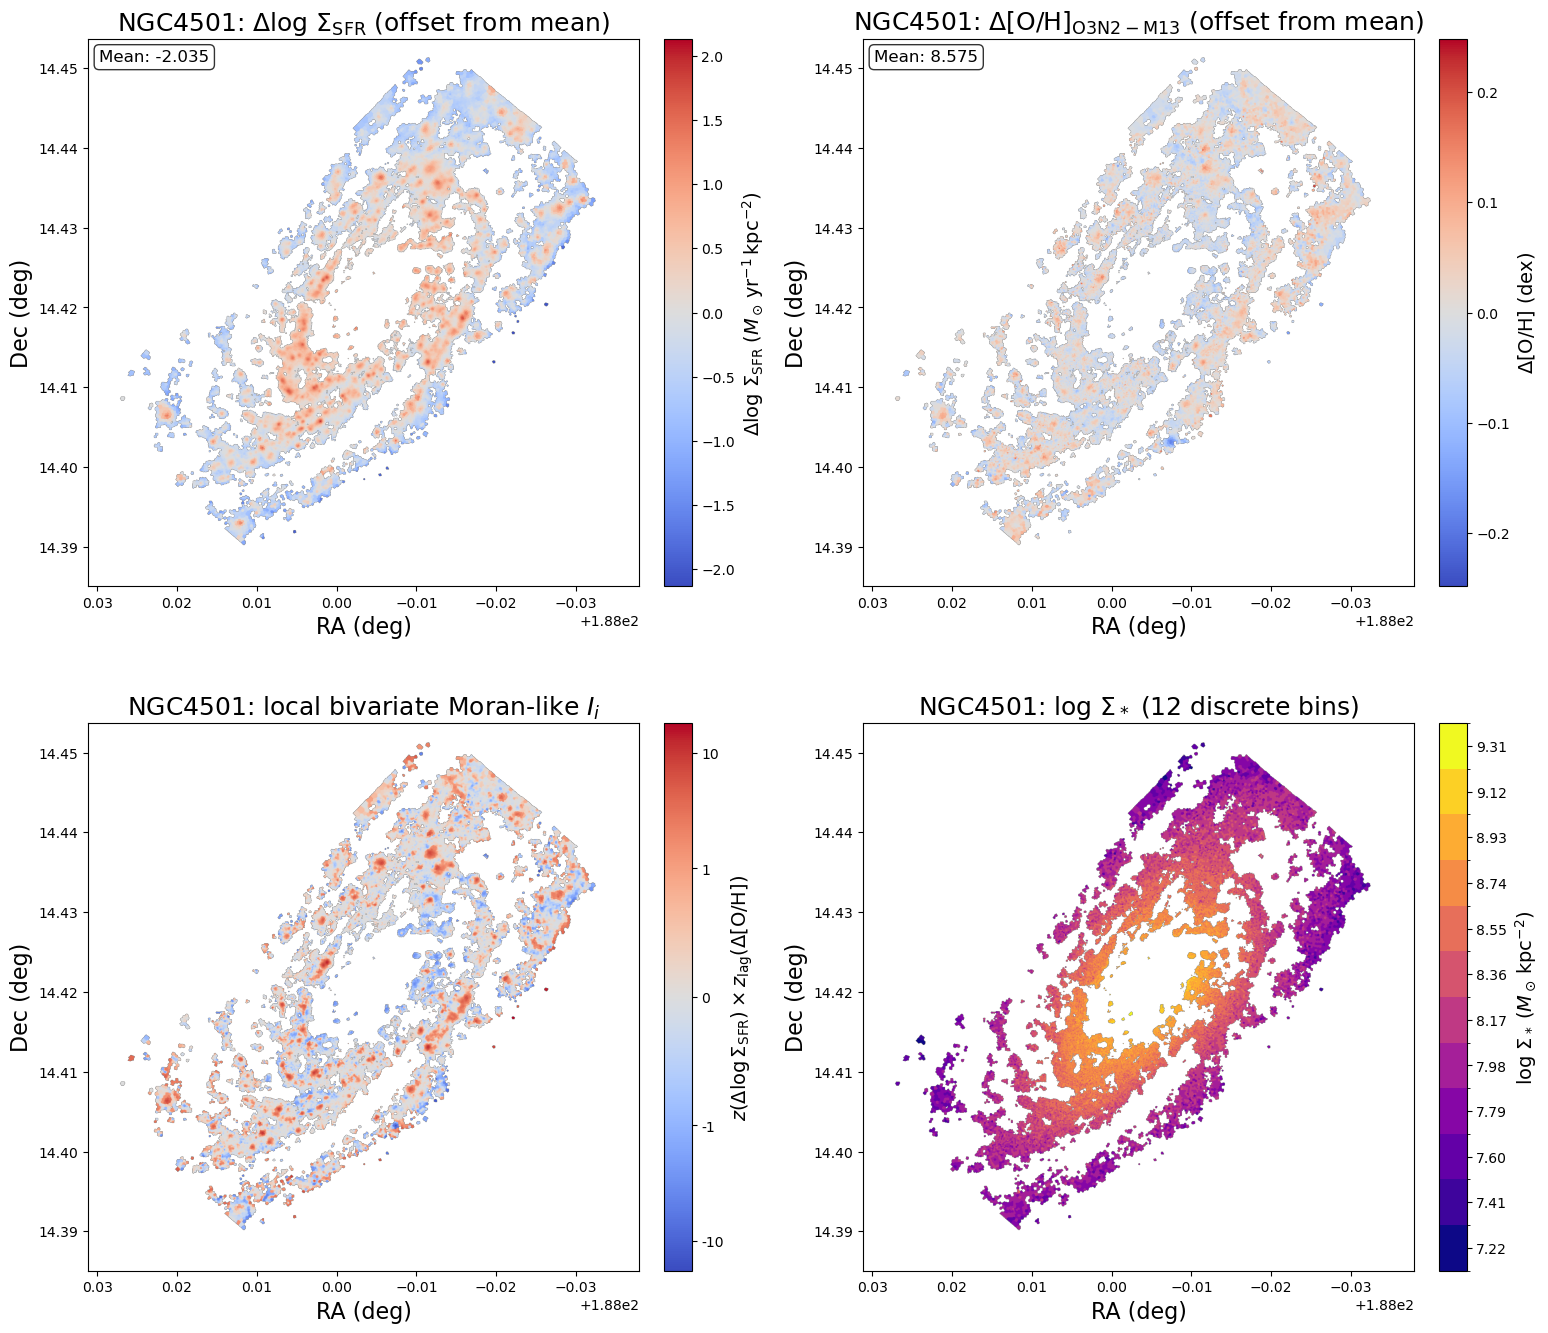


2x2 combined figure complete for NGC4501!
  Σ_SFR offset range: -2.132 to 2.132
  [O/H] offset range: -0.248 to 0.248
  Moran I_i range: -14.075 to 18.007
  Σ* bins: 12 bins from 7.128 to 9.407


In [7]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate mean values and create offset maps
    # ------------------------------------------------------------------
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
    
    sfr_offset = sigSFR - sfr_mean
    oh_offset = oh_o3n2_map - oh_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_sfr]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_oh]))

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
        """
        Simple Moran-style local bivariate association between A and B.

        Parameters
        ----------
        A, B : 2D arrays
            Maps (e.g. sfr_offset, oh_offset).
        valid_mask : 2D bool
            True where both maps are valid.
        neighbourhood : {'queen', 'rook'}
            'queen' = 8-connected neighbours, 'rook' = 4-connected.

        Returns
        -------
        I_map : 2D array
            Local bivariate Moran-like statistic (sign & amplitude).
        quad_map : 2D int array
            Quadrant type:
            0 = invalid / no neighbours
            1 = high A, high lag(B)
            2 = low A,  high lag(B)
            3 = low A,  low lag(B)
            4 = high A, low lag(B)
        """
        ny, nx = A.shape
        I_map = np.full_like(A, np.nan, dtype=float)
        quad_map = np.zeros_like(A, dtype=int)

        # standardise A,B on valid pixels only
        Aval = A[valid_mask]
        Bval = B[valid_mask]
        Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
        Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

        if neighbourhood == 'queen':
            offsets = [(-1,-1), (-1,0), (-1,1),
                       ( 0,-1),          ( 0,1),
                       ( 1,-1), ( 1,0), ( 1,1)]
        elif neighbourhood == 'rook':
            offsets = [(-1,0), (0,-1), (0,1), (1,0)]
        else:
            raise ValueError("neighbourhood must be 'queen' or 'rook'")

        for i in range(ny):
            for j in range(nx):
                if not valid_mask[i, j]:
                    continue

                # collect neighbouring Bz values
                neigh_vals = []
                for dy, dx in offsets:
                    ii, jj = i + dy, j + dx
                    if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                        neigh_vals.append(Bz[ii, jj])

                if len(neigh_vals) == 0:
                    continue

                lag_B = np.mean(neigh_vals)   # spatial lag of B
                I_val = Az[i, j] * lag_B      # Moran-style product
                I_map[i, j] = I_val

                # quadrant classification (like LISA maps)
                if Az[i, j] >= 0 and lag_B >= 0:
                    quad_map[i, j] = 1  # high A – high B_neigh
                elif Az[i, j] < 0 and lag_B >= 0:
                    quad_map[i, j] = 2  # low A – high B_neigh
                elif Az[i, j] < 0 and lag_B < 0:
                    quad_map[i, j] = 3  # low A – low B_neigh
                else:
                    quad_map[i, j] = 4  # high A – low B_neigh

        return I_map, quad_map
    
    I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                            neighbourhood='queen')
    
    # Still need n_bins for bottom-right plot
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    ax1.text(0.02, 0.98, f'Mean: {sfr_mean:.3f}', transform=ax1.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)
    
    ax2.text(0.02, 0.98, f'Mean: {oh_mean:.3f}', transform=ax2.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-left: Moran-like bivariate map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    # max absolute value for symmetric limits
    vI = np.nanmax(np.abs(I_map))
    
    # Symmetric log-normalisation:
    #  - linthresh=1.0   → values between -1 and 1 are on a linear scale
    #  - outside this, log10 scaling, symmetric around 0
    norm = SymLogNorm(linthresh=1.0, linscale=1.0,
                      vmin=-vI, vmax=vI, base=10)
    
    imI = ax3.imshow(np.ma.masked_invalid(I_map), origin='lower',
                     cmap='coolwarm', extent=extent, norm=norm)
    ax3.set_title(rf'{gal}: local bivariate Moran-like $I_i$', fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbarI = fig.colorbar(imI, ax=ax3, fraction=0.046, pad=0.04)
    cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$', fontsize=14)
    
    # Nice symmetric log-style ticks (…,-10,-3,-1,0,1,3,10,…)
    max_pow = int(np.floor(np.log10(vI)))
    pos_ticks = [10**k for k in range(0, max_pow+1) if 10**k <= vI]
    ticks = [-p for p in reversed(pos_ticks)] + [0.0] + pos_ticks
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f'{t:g}' for t in ticks])

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    plt.savefig(f'{gal}_correlation_map_moran.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{gal}_correlation_map_moran.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  Moran I_i range: {np.nanmin(I_map):.3f} to {np.nanmax(I_map):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")
